# Example of using the <tt>fdac</tt> package on the CoRoT-7 data from Queloz et al (2009) and Haywood et al. (2014)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import plotly.express as ex
from finufft import nufft1d3
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from scipy.stats import trim_mean, chi2
from math import ceil
import seaborn as sn
import scienceplots
plt.style.use(['science','notebook','grid'])
plt.rcParams['text.usetex'] = True
plt.rcParams.update({"font.size" : 26})
plt.rcParams.update({"axes.labelsize" : 24})
plt.rcParams.update({"xtick.labelsize" : 22})
plt.rcParams.update({"ytick.labelsize" : 22})
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

## CoRoT-7 

### Queloz et. al (2009) data 

In [3]:
quel09 = pd.read_table('../../data/CoRoT-7_Queloz09_spec.txt',comment ='#', delim_whitespace=True,\
                      header = None, names= ['JDB','RV','e_RV','FWHM','e_FWHM','Span',\
                                            'e_Span',"log(R'(HK))", "e_log(R'(HK))"])
quel09.head()

/var/folders/yk/b36tymm90p1cnv5qffdwp2z40000gn/T/ipykernel_60695/721997005.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  quel09 = pd.read_table('../../data/CoRoT-7_Queloz09_spec.txt',comment ='#', delim_whitespace=True,\


,JDB,RV,e_RV,FWHM,e_FWHM,Span,e_Span,log(R'(HK)),e_log(R'(HK))
0,2.454528e+06,31.1818,0.0015,6.4648,0.0035,0.0258,0.0030,-4.6646,0.0059
1,2.454531e+06,31.1732,0.0015,6.4666,0.0035,0.0309,0.0030,-4.6736,0.0063
2,2.454551e+06,31.1972,0.0021,6.4621,0.0049,0.0191,0.0042,-4.6269,0.0116
3,2.454776e+06,31.1881,0.0022,6.5028,0.0052,0.0340,0.0044,-4.5847,0.0103
4,2.454777e+06,31.1848,0.0028,6.4981,0.0066,0.0317,0.0056,-4.5702,0.0151


In [4]:
#convert values in floats
for i in range(len(quel09.columns)):
    quel09.iloc[:,i] = pd.to_numeric(quel09.iloc[:,i], errors='coerce')

In [5]:
# set the initial obervation time to 0
quel09['shifted_JD'] = quel09['JDB'] - quel09.iloc[0]['JDB']
quel09['RV'] = (quel09['RV'] - np.mean(quel09['RV']))*1000
quel09['e_RV'] = quel09['e_RV']*1000
#erase the first three measurements due to the large gaps between observations
quel09 = quel09[3:]
print('Lenght of the data set:', len(quel09))

Lenght of the data set: 106


Text(0.5, 1.0, 'RV CoRoT-7 Queloz et. al (2009)')

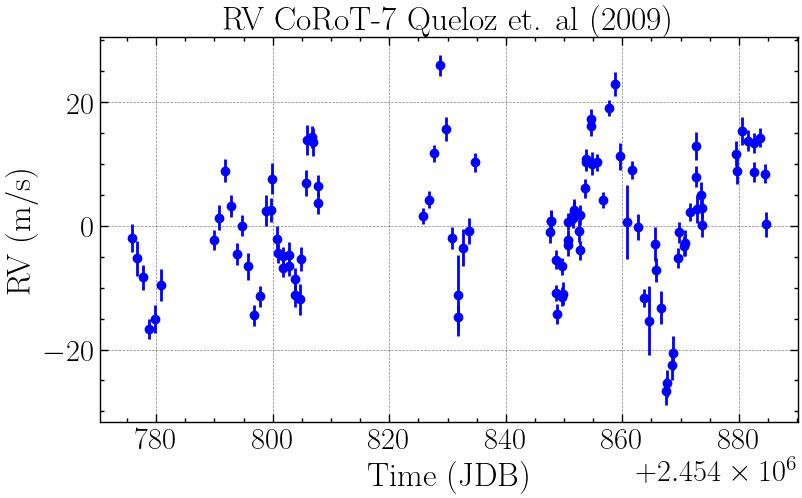

In [6]:
#plot one more time
plt.figure(figsize=(9,5))
plt.errorbar(quel09['JDB'], quel09['RV'], yerr = quel09['e_RV'], fmt = 'o', color = 'b')
plt.ylabel('RV (m/s)')
plt.xlabel('Time (JDB)')
plt.title('RV CoRoT-7 Queloz et. al (2009)', fontsize = 24)

In [7]:
time_quel =  quel09['JDB']
obs_quel = np.array([quel09['RV'], quel09['FWHM'], quel09['Span'], quel09['log(R\'(HK))']])
names_quel = ['RV', 'FWHM', 'Span', 'log(HK)']

In [11]:
import sys
import os

# Get the path to the src folder relative to the notebook
src_path = os.path.abspath(os.path.join(os.pardir,os.pardir, "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

#Import the module
from fdac import fdac

In [12]:
obs_quel.shape

(4, 106)

In [13]:
fdac_quel = fdac.fdac(np.array(time_quel), obs_quel[0],obs_quel[1:],  names_quel)

Mean Nyquist frequency:  0.4824157617086172 

Median Nyquist frequency:  0.5498723196737622 

10% trimmed Mean Nyquist frequency:  0.7684286541606052 

20% trimmed mean Nyqusit frequenct:  0.7543872008988005


frequency associated with the median timestep. Make sure that makes
sense for your dataset.


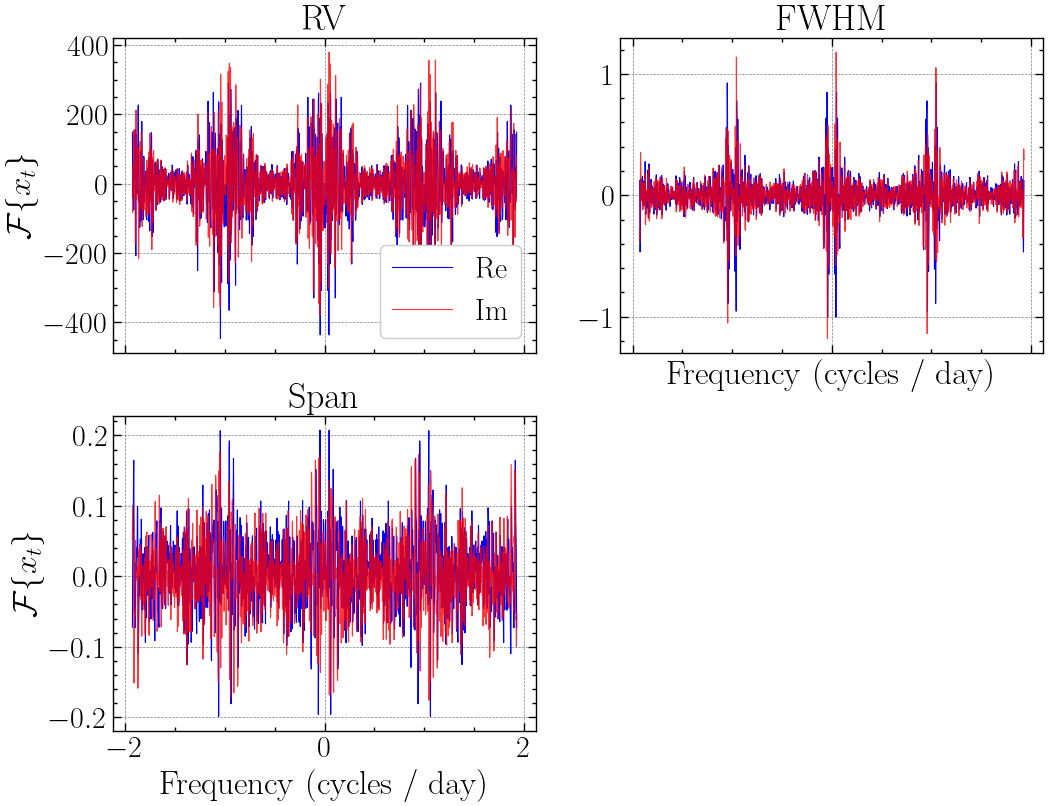

In [14]:
fdac_quel.frequency_grid(4*fdac_quel.Nyq_meandt, oversample=4)
fdac_quel.computeNFFT()
fdac_quel.plotNFFT()

Coefficients
----
Coefficients: 
 [[ 184.09386204  -44.01008356 -405.46094348  -23.68368463  -50.41017118
     3.36816131]
 [  46.07520358  183.42775275   28.60285633 -408.48594388   -3.42057022
   -49.67680027]]

Intercept
---------
Intercept: 
 0.0


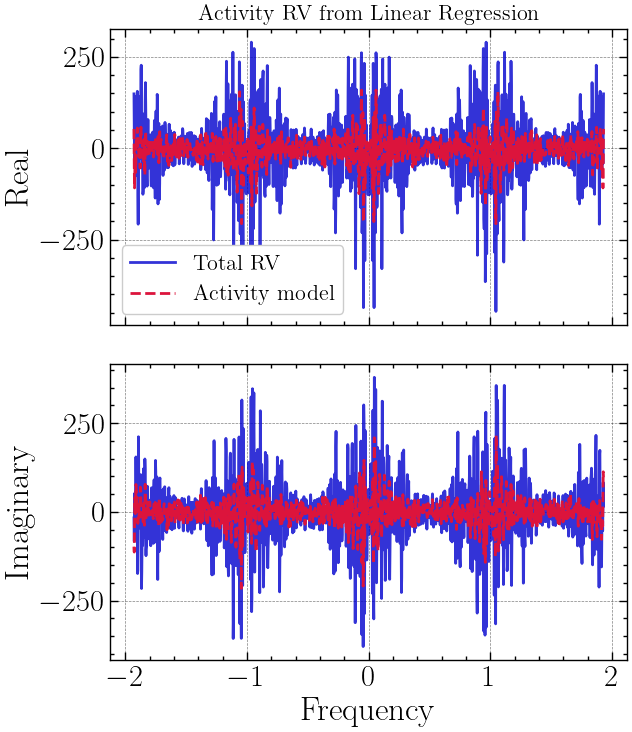

In [15]:
fdac_quel.linear_reg()
fdac_quel.fftac_plot()

10.057194125374638 1.314500283984792e-06
Raw standard deviation 10.3005
Variance ratio: 0.1558
Should be 1: 1.0000000000000002
Should be equal: 4.0659 4.0659
Inversion fully computed
Std dev of clean RV: 9.608223635108892


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


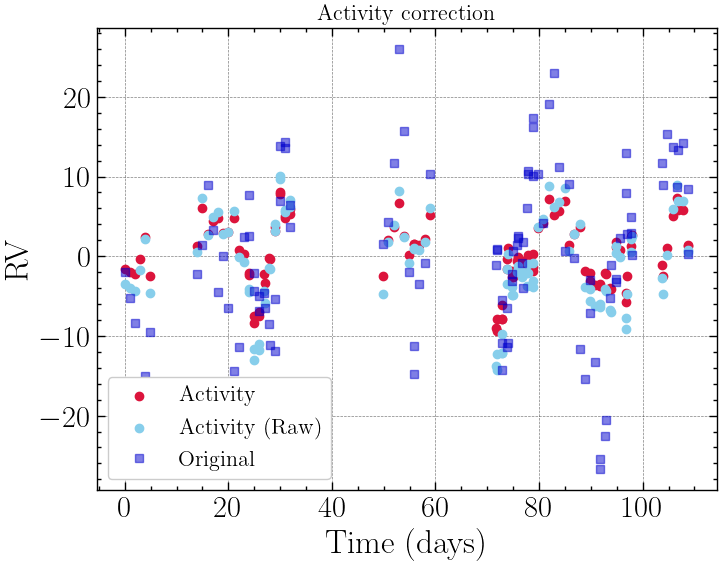

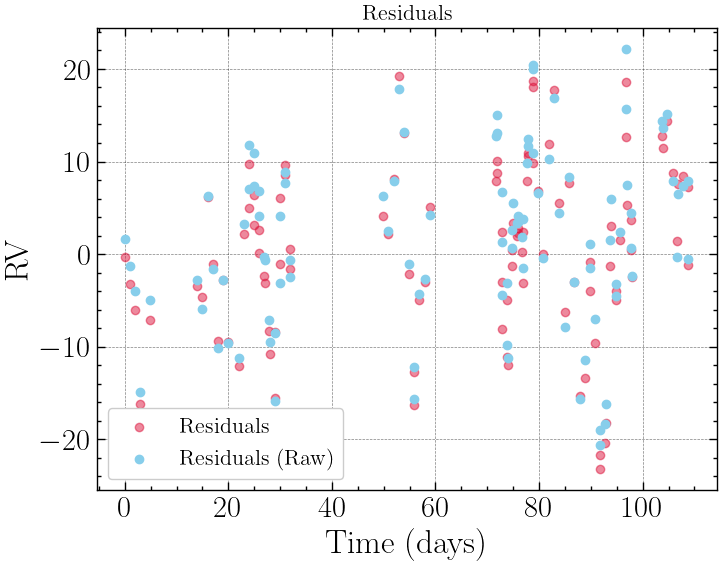

In [16]:
fdac_quel.inverfft()
fdac_quel.activityplot(clean = True)

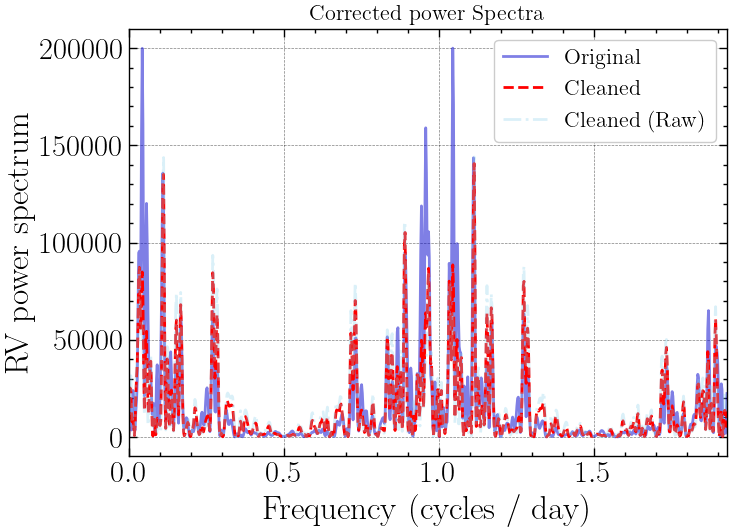

In [17]:
fdac_quel.residual_powplot()

(0.0, 0.6)

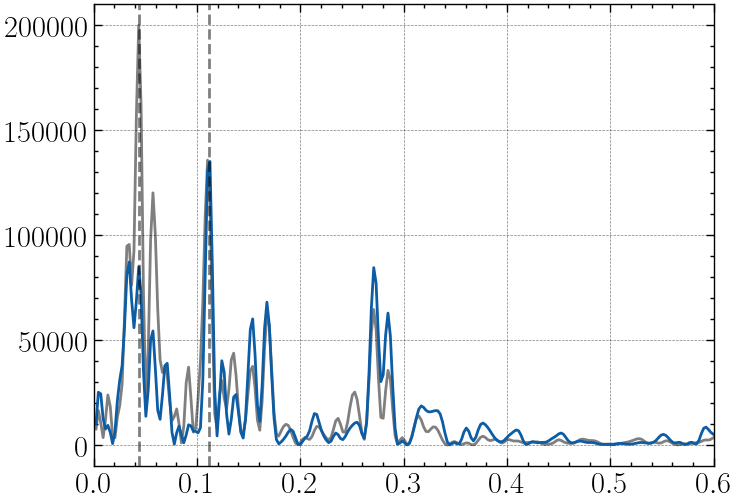

In [23]:
indeces = fdac_quel.fgrid>=0
plt.plot(fdac_quel.fgrid[indeces], np.abs(fdac_quel.first_FFT[indeces])**2, color='k', alpha=0.5)
plt.plot(fdac_quel.fgrid[indeces], np.abs(fdac_quel.residuals_FFT[indeces])**2,alpha=1)
#plt.axvline(1/42, color='k', ls='--', alpha=0.5)
plt.axvline(1/23, color='k', ls='--', alpha=0.5)
plt.axvline(1/8.96, color='k', ls='--', alpha=0.5)
plt.xlim(0, 0.6)

## Haywood et. al (2014) data 

In [13]:
from pathlib import Path

# This gets the path where the current notebook is located
notebook_path = Path().resolve()
# Change working directory to the notebook's directory
os.chdir(notebook_path)

In [14]:
haydata = pd.read_csv('../data/CoRoT-7_Haywood14_spec.txt', sep = '\t', skiprows = 7)
haydata.columns = ['JDB', 'RV', 'e_RV', 'FWHM', 'BIS', "log(R'(HK))", "e_log(R'(HK))"]
haydata.head()

,JDB,RV,e_RV,FWHM,BIS,log(R'(HK)),e_log(R'(HK))
0,2.455940e+06,31.18031,0.00233,6.45633,0.01199,4.6990,0.0180
1,2.455940e+06,31.17814,0.00212,6.46445,0.01966,4.7188,0.0173
2,2.455941e+06,31.18283,0.00251,6.46592,0.01956,4.6982,0.0210
3,2.455941e+06,31.17833,0.00271,6.45650,0.03679,4.7789,0.0283
4,2.455941e+06,31.18415,0.00215,6.46568,0.01359,4.7204,0.0180


In [15]:
#change units
haydata['shifted_JD'] = haydata['JDB'] - haydata.iloc[0]['JDB']
haydata['RV'] = (haydata['RV'] - np.mean(haydata['RV']))*1000
haydata['e_RV'] = haydata['e_RV']*1000

Text(0.5, 1.0, 'RV CoRoT-7 Haywood et. al (2014)')

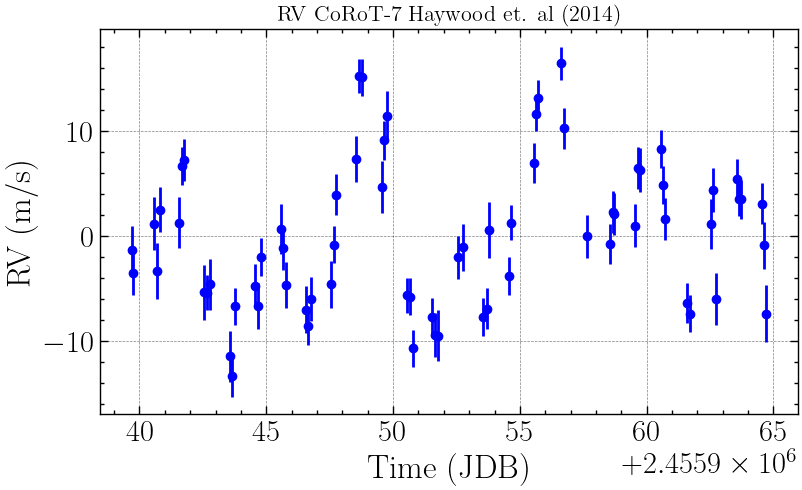

In [16]:
plt.figure(figsize = (9,5))
plt.errorbar(haydata['JDB'], haydata['RV'], yerr = haydata['e_RV'], fmt = 'o', color = 'b')
plt.ylabel('RV (m/s)')
plt.xlabel('Time (JDB)')
plt.title('RV CoRoT-7 Haywood et. al (2014)', fontsize = 16)

In [17]:
time_hay = haydata['JDB']
names_hay = ['RV', 'FWHM', 'BIS', 'log(HK)']
obs_hay = np.array([haydata['RV'], haydata['FWHM'], haydata['BIS'], haydata['log(R\'(HK))']])
fdac_hay = fdac.fdac(time_hay, obs_hay[0], obs_hay[1:], names_hay)

Mean Nyquist frequency:  1.3997693180067394 

Median Nyquist frequency:  4.710981307335369 

10% trimmed Mean Nyquist frequency:  1.4499123256279614 

20% trimmed mean Nyqusit frequenct:  1.5270930856366054


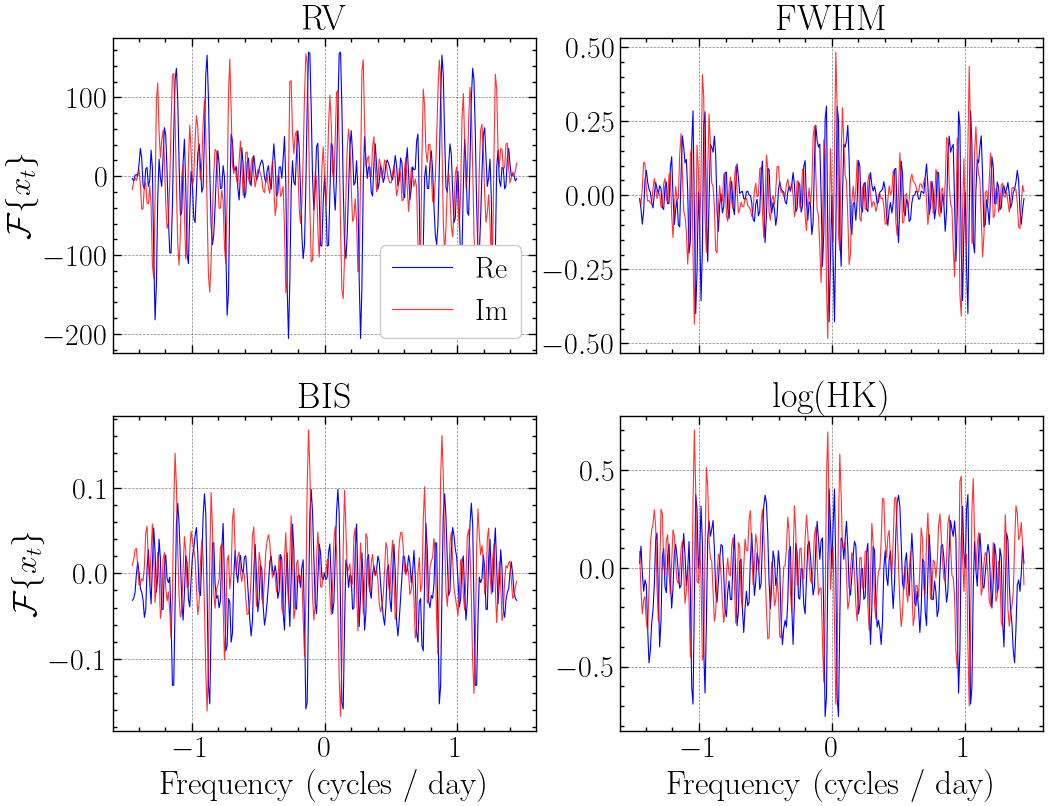

In [18]:
fdac_hay.frequency_grid(3*fdac_quel.Nyq_meandt, oversample=4)
fdac_hay.computeNFFT()
fdac_hay.plotNFFT()

Coefficients
----
Coefficients: 
 [[ 274.33855753   28.04525942 -102.80457627 -247.50816046   37.76714117
    51.22018131]
 [ -30.3862396   270.85996156  242.72307786 -125.48173943  -53.710523
    32.29528939]]

Intercept
---------
Intercept: 
 0.0


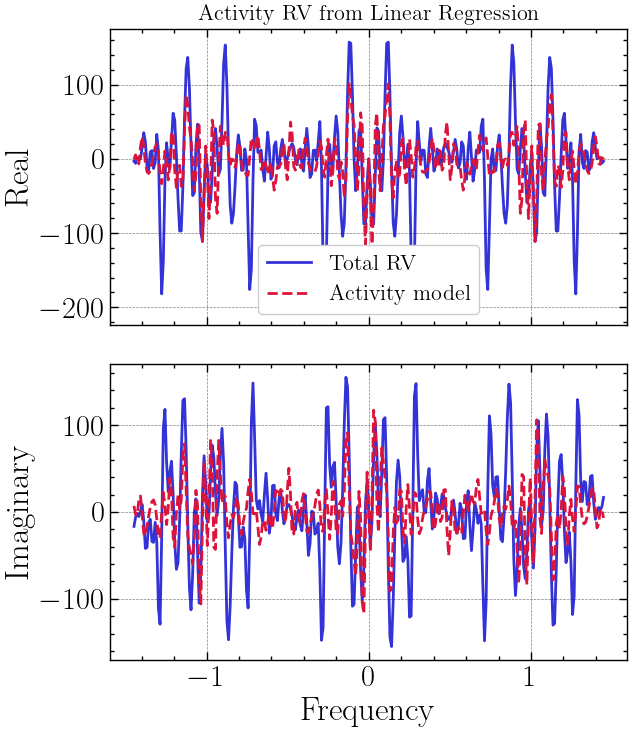

In [19]:
fdac_hay.linear_reg()
fdac_hay.fftac_plot()

15.9228722235594 8.88976028886705e-09
Raw standard deviation 6.8582
Variance ratio: 0.3029
Should be 1: 1.0000000000000002
Should be equal: 3.7743 3.7743
Inversion fully computed
Std dev of clean RV: 7.30190907082096


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


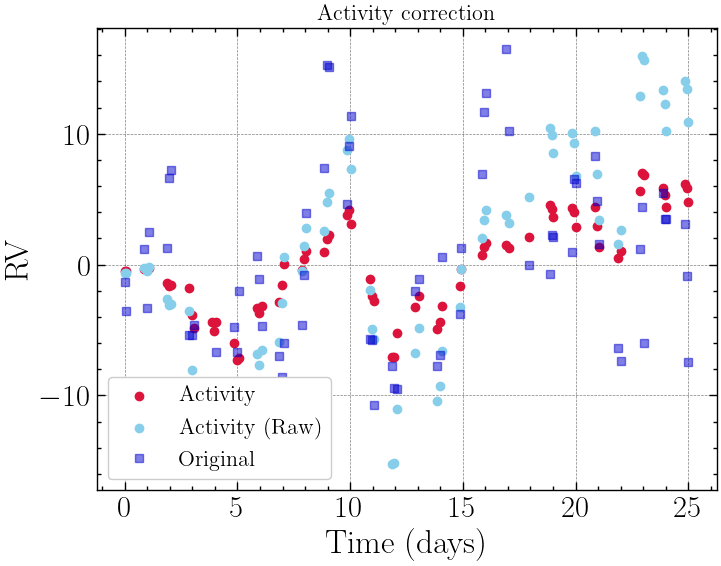

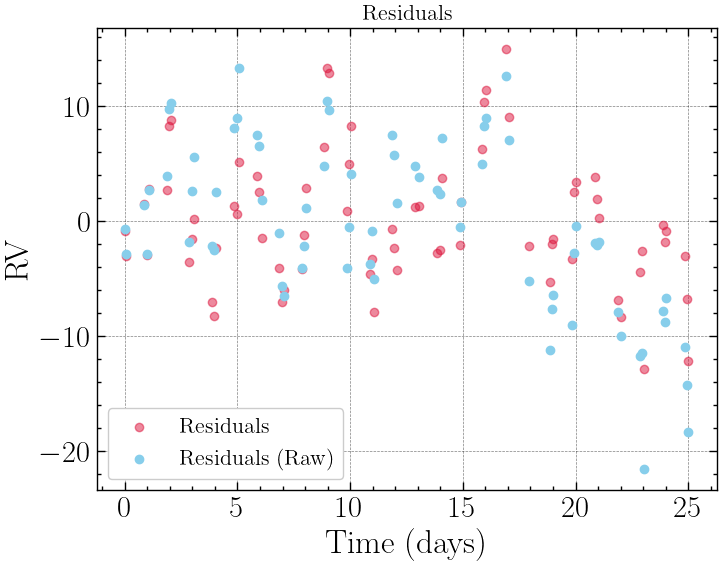

In [20]:
fdac_hay.inverfft()
fdac_hay.activityplot(clean = True)

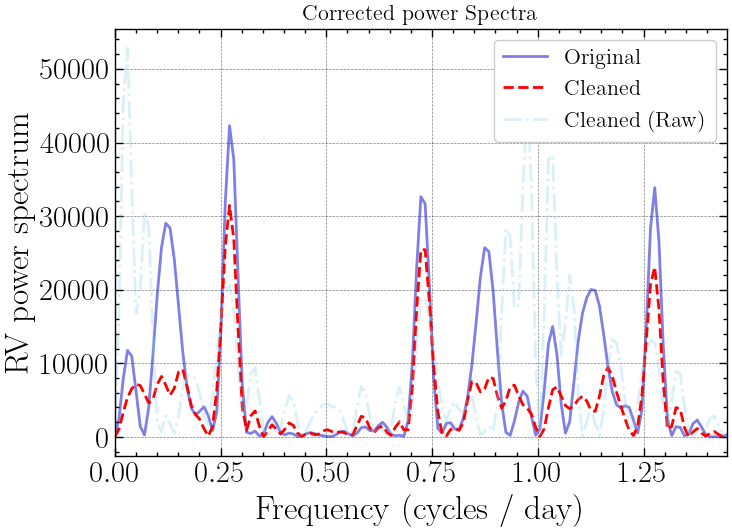

In [21]:
fdac_hay.residual_powplot()

### Both datasets together 

In [22]:
t_full = np.append(quel09['JDB'], haydata['JDB'])
rv_full = np.append(quel09['RV'], haydata['RV'])
fwhm_full = np.append(quel09['FWHM'], haydata['FWHM'])
loghk_full = np.append(np.abs(quel09['log(R\'(HK))']), haydata['log(R\'(HK))'])
bis_full = np.append(quel09['Span'], haydata['BIS'])
obs_full = np.array([rv_full, fwhm_full, bis_full, loghk_full])

In [23]:
names = ['RV', 'FWHM', 'BIS', 'log(HK)']
fdac_full = fdac.fdac(t_full, obs_full[0],obs_full[1:],names)

Mean Nyquist frequency:  0.07401896601927435 

Median Nyquist frequency:  0.6364967221122111 

10% trimmed Mean Nyquist frequency:  0.9457302843095128 

20% trimmed mean Nyqusit frequenct:  0.9488756618802644


frequency associated with the median timestep. Make sure that makes
sense for your dataset.


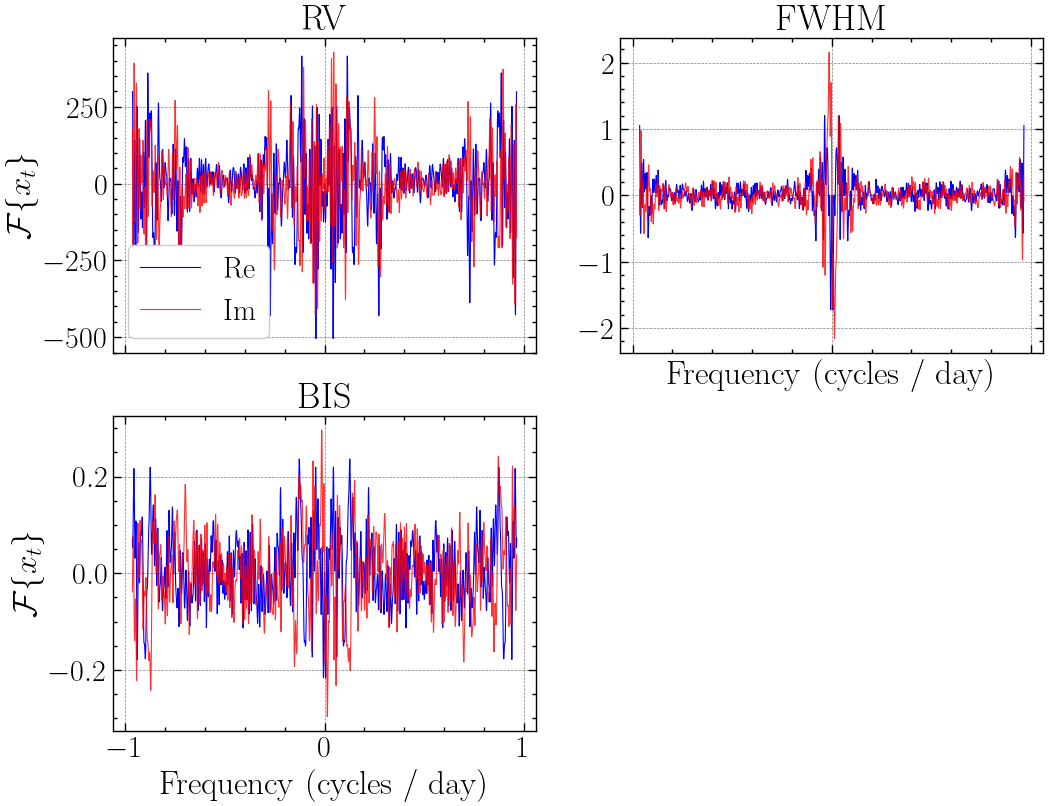

In [42]:
fdac_full.frequency_grid(2*fdac_quel.Nyq_meandt, oversample=1)
fdac_full.computeNFFT()
fdac_full.plotNFFT()

Coefficients
----
Coefficients: 
 [[ 254.6742438   -25.38404173 -236.12940965  -15.36154994   41.66159684
    -4.61482846]
 [  29.24134226  213.382738     33.01805107 -324.11856922    5.91297049
    53.99405548]]

Intercept
---------
Intercept: 
 0.0


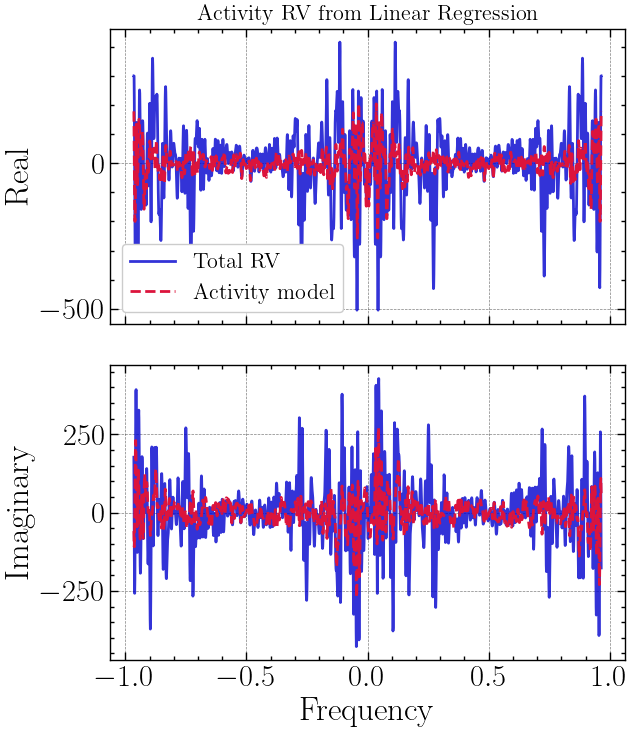

In [43]:
fdac_full.linear_reg()
fdac_full.fftac_plot()

13.711454994611145 4.515377471439853e-08
Raw standard deviation 9.0782
Variance ratio: 0.1764
Should be 1: 0.9999999999999999
Should be equal: 3.8124 3.8124
Inversion fully computed
Std dev of clean RV: 8.773233286683285


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


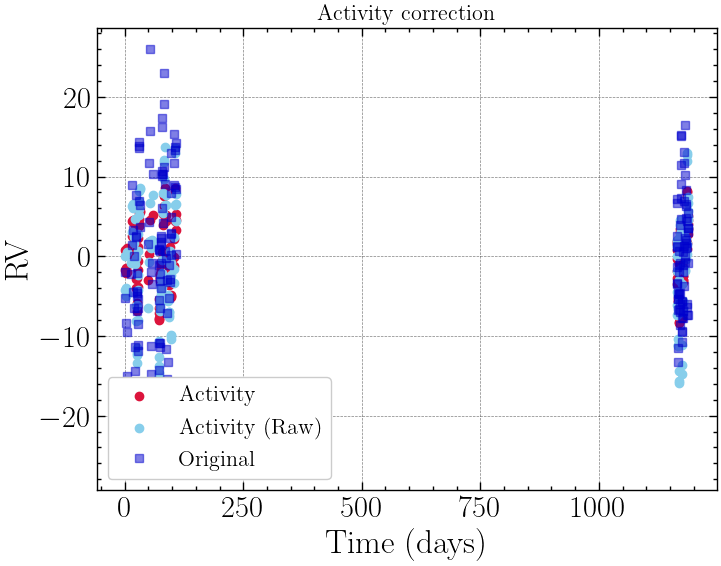

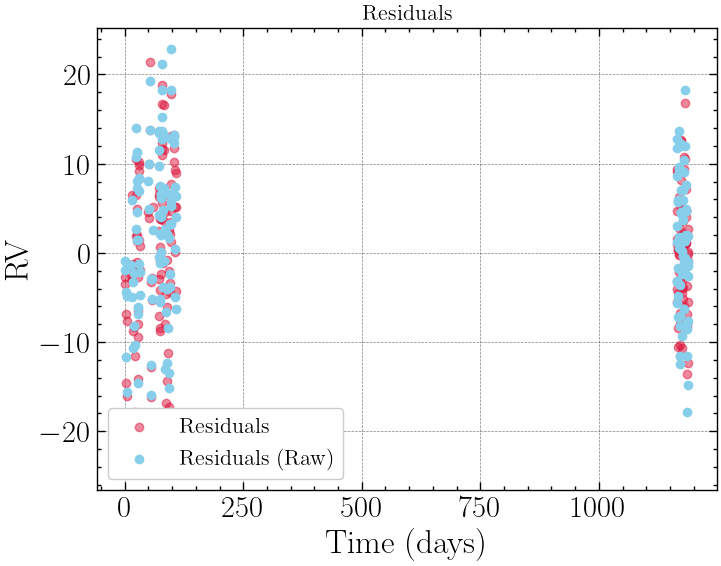

In [44]:
fdac_full.inverfft()
fdac_full.activityplot(clean = True)

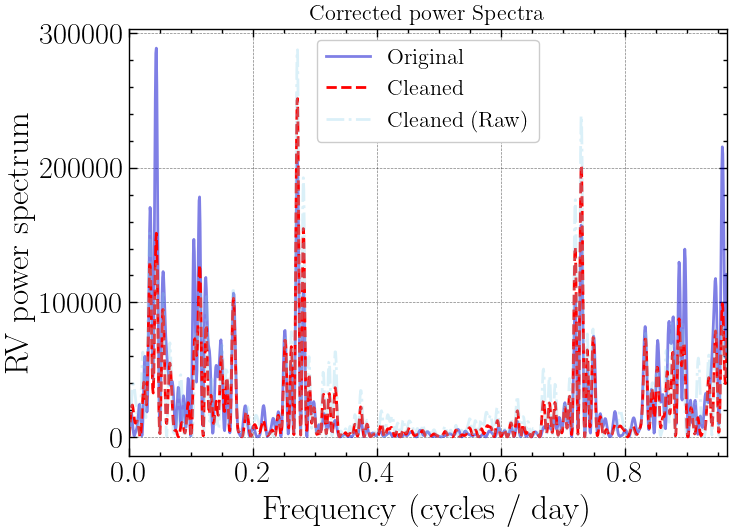

In [45]:
fdac_full.residual_powplot()

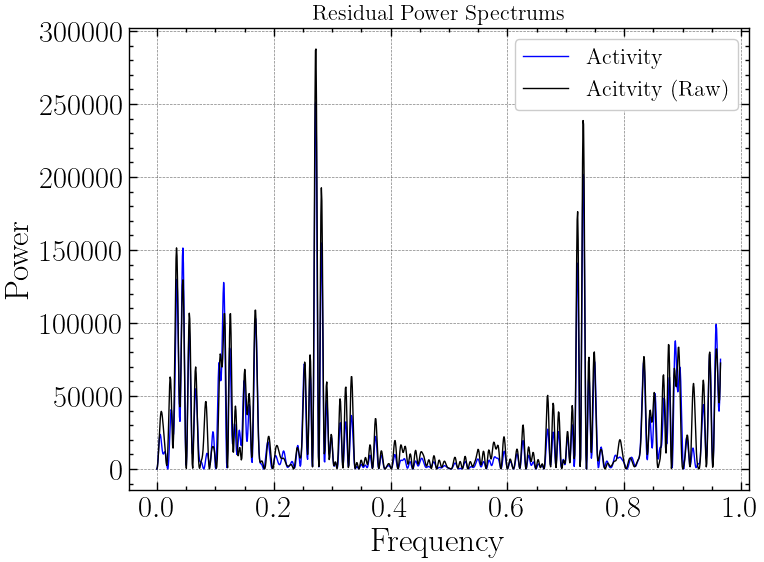

In [53]:
plt.plot(fdac_full.powfgrid, np.abs(fdac_full.residuals_FFT[fdac_full.nf:])**2, color='b', linewidth=1, label = 'Activity')
plt.plot(fdac_full.powfgrid, np.abs(fdac_full.residuals_raw_FFT[fdac_full.nf:])**2, color='k', linewidth=1, label='Acitvity (Raw)')
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.title('Residual Power Spectrums')
plt.legend()